# RBM Training

Train the RBM on the MovieLens implicit feedback matrix.

In [7]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.append(str(project_root / "src"))

from data_prep import DataConfig, load_movielens
from rbm import RBM

# 1) Load raw ratings and inspect
data_dir = project_root / "data"
ratings_candidates = ["ratings.csv", "rating.csv"]
ratings_path = None
for name in ratings_candidates:
    path = data_dir / name
    if path.exists():
        ratings_path = path
        break

if ratings_path is None:
    raise FileNotFoundError(f"No ratings file found in {data_dir}")

ratings_df = pd.read_csv(ratings_path, usecols=["userId", "movieId", "rating", "timestamp"])
print("ratings shape:", ratings_df.shape)
print(ratings_df.head())

# 2) Build implicit feedback matrices
config = DataConfig(data_dir=str(data_dir), max_users=2000, max_items=4000)
data = load_movielens(config)
train_matrix = data["train_matrix"]
test_matrix = data["test_matrix"]
print("train matrix shape:", train_matrix.shape)
print("test matrix shape:", test_matrix.shape)


ratings shape: (20000263, 4)
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40
train matrix shape: (2000, 3485)
test matrix shape: (2000, 3485)


In [8]:
# 3) Sparsity and basic statistics
n_users, n_items = train_matrix.shape
interaction_count = train_matrix.nnz
sparsity = 1.0 - interaction_count / (n_users * n_items)
print("n_users:", n_users)
print("n_items:", n_items)
print("interactions:", interaction_count)
print("sparsity:", round(sparsity, 6))

n_users: 2000
n_items: 3485
interactions: 56270
sparsity: 0.991927


In [9]:
# 4) RBM initialization and one-step Gibbs sampling
rbm = RBM(n_visible=train_matrix.shape[1], n_hidden=128, k=5)

v0 = torch.from_numpy(train_matrix[0].toarray()).float()
h_prob, h_sample = rbm.sample_h(v0)
v_prob, v_sample = rbm.sample_v(h_sample)

print("hidden prob mean:", h_prob.mean().item())
print("reconstruction prob mean:", v_prob.mean().item())

hidden prob mean: 0.5002444982528687
reconstruction prob mean: 0.4996649920940399


In [10]:
# 5) One Contrastive Divergence step
v_batch = torch.from_numpy(train_matrix[:128].toarray()).float()
loss = rbm.contrastive_divergence(v_batch, lr=0.01)
print("CD step loss:", loss)

CD step loss: 0.694568932056427


epoch=1, loss=0.680399
epoch=2, loss=0.661966
epoch=3, loss=0.644066
epoch=4, loss=0.626858
epoch=5, loss=0.610173


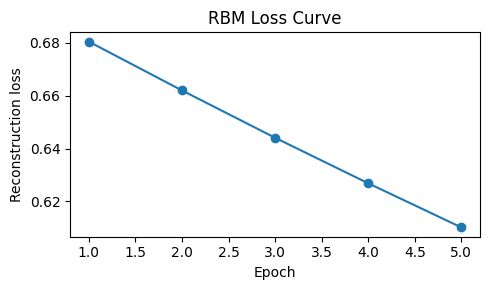

In [11]:
# 6) Train for a few epochs and plot loss
losses = []
for epoch in range(5):
    batch_losses = []
    for start in range(0, n_users, 256):
        v0 = torch.from_numpy(train_matrix[start : start + 256].toarray()).float()
        batch_losses.append(rbm.contrastive_divergence(v0, lr=0.01))
    losses.append(float(np.mean(batch_losses)))
    print(f"epoch={epoch+1}, loss={losses[-1]:.6f}")

plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("RBM Loss Curve")
plt.tight_layout()
plt.show()

In [12]:
# 7) Inference with movie titles
movie_candidates = ["movies.csv", "movie.csv"]
movie_path = None
for name in movie_candidates:
    path = os.path.join("data", name)
    if os.path.exists(path):
        movie_path = path
        break

movie_titles = {}
if movie_path:
    movie_df = pd.read_csv(movie_path, usecols=["movieId", "title"])
    movie_titles = dict(zip(movie_df["movieId"].astype(int), movie_df["title"]))

user_id = list(data["user_id_map"].keys())[0]
user_idx = data["user_id_map"][user_id]
id_to_item = {idx: mid for mid, idx in data["item_id_map"].items()}

v0 = torch.from_numpy(train_matrix[user_idx].toarray()).float()
with torch.no_grad():
    scores = rbm.reconstruct(v0).cpu().numpy().ravel()

seen_items = set(train_matrix[user_idx].indices.tolist())
scores[list(seen_items)] = -np.inf
k = 10
topk = np.argpartition(-scores, k - 1)[:k]
topk = topk[np.argsort(-scores[topk])]

print(f"Top-{k} for user_id={user_id}:")
for rank, idx in enumerate(topk.tolist(), start=1):
    movie_id = id_to_item[idx]
    title = movie_titles.get(movie_id, "UNKNOWN_TITLE")
    print(f"{rank:02d}. movieId={movie_id} | {title}")

Top-10 for user_id=37:
01. movieId=296 | UNKNOWN_TITLE
02. movieId=356 | UNKNOWN_TITLE
03. movieId=260 | UNKNOWN_TITLE
04. movieId=527 | UNKNOWN_TITLE
05. movieId=110 | UNKNOWN_TITLE
06. movieId=457 | UNKNOWN_TITLE
07. movieId=150 | UNKNOWN_TITLE
08. movieId=480 | UNKNOWN_TITLE
09. movieId=608 | UNKNOWN_TITLE
10. movieId=32 | UNKNOWN_TITLE
